# **Аналіз ефективності продажів та логістики / Sales Performance & Logistics Optimization (End-to-End Sales Analytics Case)**

*UA: У цьому проєкті ми досліджуємо операційну діяльність компанії, що здійснює глобальну торгівлю. Ефективність бізнесу залежить від трьох китів: оптимізації товарної матриці, географічного розширення та швидкості логістики (часу відвантаження замовлень).*

*EN: This project evaluates the operational efficiency of a global retail/e-commerce company. Business success in this sector relies on three pillars: product portfolio optimization, geographical expansion, and supply chain efficiency (order-to-shipment duration).*

ENVIRONMENT SETUP & DATA LOADING

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

In [ ]:
# Mount Google Drive to access project assets
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Navigate to the project directory
%cd /content/drive/MyDrive/Mate_homework

/content/drive/MyDrive/Mate_homework


In [ ]:
# Load operational source datasets
events = pd.read_csv("events.csv")
countries = pd.read_csv("countries.csv")
products = pd.read_csv("products.csv")

In [ ]:
# Quick data dimension validation (Shape Check)
print(f"Events table dimensions:    {events.shape}")
print(f"Countries table dimensions: {countries.shape}")
print(f"Products table dimensions:  {products.shape}")

Events table dimensions:    (1330, 10)
Countries table dimensions: (249, 5)
Products table dimensions:  (12, 2)


##**Етап 1: Огляд даних (Data Overview)**
На цьому етапі проведено первинний аудит трьох джерел даних (замовлення, товари, географія):

* Розібрано зміст та типи колонок, сформовано їхній технічний опис.

* Виявлено ключові поля **Primery Keys** та **Foreign Keys**, що пов'язують таблиці між собою, для подальшого об'єднання в єдину аналітичну модель.

## **Step 1: Data Overview**
During this initial phase, a structural and qualitative audit was conducted across the three data streams (Orders, Geography, and Product Nomenclature):
* Analyzed column semantic meanings, data types, and structural alignment.
* Identified **Primary Keys (PK)** and **Foreign Keys (FK)** required to join independent source files into a unified relational schema for downstream analysis.

In [ ]:
# Inspect initial rows to understand layout, formatting, and values
display(events.head(3))
display(countries.head(3))
display(products.head(3))

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes


## **Схема даних та зв'язки між сутностями**

## **Data Schema & Entity Relations**

## **Структура даних та зв'язки між сутностями / Data Schema & Entity Relations**

### **Специфікація таблиці `events` (Реєстр замовлень)**
| Стовпець | Технічний опис |
| :--- | :--- |
| **Order ID** | Унікальний ідентифікатор транзакції (замовлення) |
| **Order Date / Ship Date** | Часові мітки (дати) оформлення замовлення та його передачі в логістику |
| **Order Priority** | Категоріальна шкала пріоритетності та терміновості доставки |
| **Country Code** | Географічний код країни призначення (Зовнішній ключ) |
| **Product ID** | Товарний код позиції (Зовнішній ключ) |
| **Sales Channel** | Канал збуту та виконання замовлення (Онлайн / Офлайн) |
| **Units Sold** | Кількісний обсяг проданих товарів в рамках однієї транзакції |
| **Unit Price** | Роздрібна ціна за одиницю товару (SKU) |
| **Unit Cost** | Оптова собівартість одиниці товару (SKU) |

### **Специфікація таблиці `countries` (Географічні виміри)**
| Стовпець | Технічний опис |
| :--- | :--- |
| **Name** | Повна геополітична назва країни |
| **alpha-2** | Стандартизований дволітерний код країни (ISO) |
| **alpha-3** | Стандартизований трилітерний код країни (Первинний ключ) |
| **Region / Sub-region** | Макро- та мікрокатегоризація глобальних ринків збуту |

### **Специфікація таблиці `products` (Каталог товарів)**
| Стовпець | Технічний опис |
| :--- | :--- |
| **id** | Унікальний ідентифікатор товарної позиції / SKU (Первинний ключ) |
| **item_type** | Комерційна категорія товару верхнього рівня |

---

### **🔗 Реляційна схема та об'єднання таблиць (Entity Joins)**
Для побудови єдиної аналітичної вітрини даних та використання операційних метрик, окремі джерела даних поєднуються за допомогою таких логічних зв'язків:
1. **`events` ➡️ `countries`**: Зв'язок через `events['Country Code']` (Зовнішній ключ / FK) 🔗 `countries['alpha-3']` (Первинний ключ / PK)
2. **`events` ➡️ `products`**: Зв'язок через `events['Product ID']` (Зовнішній ключ / FK) 🔗 `products['id']` (Первинний ключ / PK)

### **`events` Table Structural Definitions (Order Registry)**
| Column | Technical Description |
| :--- | :--- |
| **Order ID** | Unique transaction identifier |
| **Order Date / Ship Date** | Timestamps tracking order placement and logistics handoff |
| **Order Priority** | Categorical scale mapping delivery urgency |
| **Country Code** | Geographical destination key (Foreign Key) |
| **Product ID** | Inventory item key (Foreign Key) |
| **Sales Channel** | Fulfillment method (Online vs. Offline) |
| **Units Sold** | Quantitative volume of goods purchased per transaction |
| **Unit Price** | Retail price per individual stock-keeping unit (SKU) |
| **Unit Cost** | Wholesale cost price per individual stock-keeping unit (SKU) |

### **`countries` Table Structural Definitions (Geographical Dimensions)**
| Column | Technical Description |
| :--- | :--- |
| **Name** | Complete geopolitical country name |
| **alpha-2** | Standardized 2-letter ISO country code |
| **alpha-3** | Standardized 3-letter ISO country code (Primary Key) |
| **Region / Sub-region** | Macro and micro geographical market categorizations |

### **`products` Table Structural Definitions (Product Catalog)**
| Column | Technical Description |
| :--- | :--- |
| **id** | Unique stock-keeping unit identifier (Primary Key) |
| **item_type** | High-level commercial product category |

### **🔗 Relational Schema & Entity Joins**
To construct a master flat-file database for execution metrics, entities will be joined via the following structural links:
1. **`events` ➡️ `countries`**: Linked via `events['Country Code']` (FK) 🔗 `countries['alpha-3']` (PK)
2. **`events` ➡️ `products`**: Linked via `events['Product ID']` (FK) 🔗 `products['id']` (PK)

## **Етап 2: Очищення даних та забезпечення їхньої цілісності**

Перш ніж будувати графіки та рахувати прибуток, потрібно переконатися, що дані на 100% точні та їм можна довіряти. Для цього я провела повне очищення:
* **Робота з пропусками (Missing Values):** Знайшла, де бракує даних, зрозуміла причини (технічні збої чи людський фактор) і вирішила, які рядки можна безпечно заповнити, а які краще видалити.
* **Виправлення форматів (Type Conversions):** Перетворила дати з текстового формату на справжні дати, а також налаштувала відображення чисел, щоб усі математичні розрахунки працювали без помилок.
* **Наведення порядку в тексті (Deduplication):** Почистила текстові колонки — прибрала випадкові пробіли та перевела все у великі літери. Це потрібно, щоб система не сприймала ту саму країну чи товар як два різні значення через дрібні розбіжності.
* **Пошук аномалій (Anomaly Detection):** Перевірила фінансові показники на наявність дивних відхилень, мінусових цін або нереальних термінів доставки, які могли б спотворити фінальні бізнес-висновки.

---

## **Step 2: Data Cleaning & Integrity Management**

Before diving into charts and metrics, we need to make sure our data is 100% accurate and trustworthy. To do this, we ran a thorough cleaning process:
* **Fixing Gaps (Missing Values):** Found where data was missing, figured out why it happened (like system bugs or human errors), and carefully decided whether to fill it in or delete it.
* **Correcting Formats (Type Conversions):** Made sure dates are recognized as actual dates (not just text), and numbers are properly formatted so our calculations work perfectly.
* **Standardizing Text (Deduplication):** Cleaned up text columns by removing accidental spaces and making all letters uppercase. This stops the system from treating the same country or product as two different things.
* **Spotting Inconsistencies (Anomaly Detection):** Scanned our numbers to check for weird outliers, negative prices, or impossible delivery timelines that could mess up our final business conclusions.

In [ ]:
# Check absolute count and percentage of missing values in the Events table
events_missing_count = events.isna().sum()
events_missing_pct = (events.isna().sum() / len(events)) * 100

print("--- Events Table Missingness Audit ---")
for col in events.columns:
    if events_missing_count[col] > 0:
        print(f"Column '{col}': {events_missing_count[col]} missing records ({events_missing_pct[col]:.2f}%)")

--- Events Table Missingness Audit ---
Column 'Country Code': 82 missing records (6.17%)
Column 'Units Sold': 2 missing records (0.15%)


### **Обробка пропущених значень у таблиці `events`**

* **Стовпець `Country Code` (82 пропущені рядки):** Якщо придивитися до цих замовлень, у них немає нічого спільного — різні дати, різні товари та канали продажів. Це схоже на звичайний технічний збій при завантаженні даних або менеджер просто забув вказати країну при оформленні.
  
  **Стратегія:** Оскільки всі фінансові показники (ціни, собівартість) у цих рядках на місці, їх видалення штучно занизило б підсумковий виторг. Тому залишаємо ці замовлення, а замість пропуску пишемо зрозуміле значення `"UNKNOWN"`.

* **Стовпець `Units Sold` (2 пропущені рядки):** У нас є всього 2 рядки, де взагалі не вказано кількість проданого товару. Оскільки в системі є лише ціна за одну штуку, але немає фінальної загальної суми чека, ми чисто математично не можемо вирахувати, скільки саме штук там було куплено.
  
  **Стратегія:** Заповнювати пропуски середнім значенням — це «пальцем в небо», що лише зіпсує нам аналітику. Тому найправильніше рішення тут — просто видалити ці 2 рядки.

---

### **Handling Missing Values in `events` table**

* **Column `Country Code` (82 missing rows):** Exploratory lookup shows that these rows feature completely distinct order dates, varied sales channels, and multiple product profiles. There is no underlying common pattern explaining the drop; it points to a standard API integration drift or localized offline order management gaps.
  
  **Strategy:** Since vital transaction footprints (pricing and sales metrics) are fully intact, dropping these lines would artificiality lower top-line revenue records. Thus, missing entities are imputed with a standardized string label: `"UNKNOWN"`.

* **Column `Units Sold` (2 missing rows):** Since the database logs only static item baseline pricing and cost margins without recording an aggregated order total value column, there is no structural mathematical pathway to accurately back-calculate or impute the true order quantities. Imputing via statistical aggregations (mean or median) would inject noise into transactional logs.
  
  **Strategy:** Drop these 2 lines entirely.

In [ ]:
# Impute missing Country Code with a designated categorical string label
events["Country Code"] = events["Country Code"].fillna("UNKNOWN")

# Drop critical rows where transactional quantity cannot be inferred
events = events.dropna(subset=["Units Sold"])

# Verify changes in events table
print(f"Remaining missing items in Events: {events.isna().sum().sum()}")

Remaining missing items in Events: 0


### **Обробка пропущених значень у таблиці `countries`**

* **Стовпець `alpha-2` (1 пропущений рядок):** Оскільки для подальшого об'єднання таблиць (joins) я використовую виключно трилітерний формат `alpha-3` (який є нашим первинним ключем), цей пропуск не несе жодних операційних ризиків. Дані не втратяться, тому заповнювати його немає жодної потреби.

* **Стовпці `region` та `sub-region` (1 пропущений рядок):** Цей пропуск виявлено в єдиному рядку, який відповідає Антарктиді. Згідно зі стандартною географічною класифікацією ООН, Антарктида виділена в окремий власний регіон, а суб-регіону вона просто не має.
  
  **Стратегія:** Щоб прибрати порожні клітинки (null) і уникнути системних помилок при групуванні, я явно прописую значення `"ANTARCTIC"` для регіону та `"UNKNOWN"` для суб-регіону.

---

### **Handling Missing Values in `countries` table**

* **Column `alpha-2` (1 missing row):** Because downstream relational joins lean entirely on the `alpha-3` primary key format, this gap introduces zero operational risk to internal entity merging. No imputation is necessary.

* **Column `region` & `sub-region` (1 missing row):** The data gap isolates directly to a record capturing Antarctica. Per standard UN macrographic definitions, Antarctica is classified under its own regional footprint with no applicable sub-region.
  
  **Strategy:** Explicitly fill the null instances with `"ANTARCTIC"` and `"UNKNOWN"` to eliminate system data gaps.

In [ ]:
# Impute regional attributes for specific non-standard geographical zones
countries["region"] = countries["region"].fillna("ANTARCTIC")
countries["sub-region"] = countries["sub-region"].fillna("UNKNOWN")

print("--- Countries & Products Structural Gaps Audit ---")
print(f"Remaining missing in Countries: {countries.isna().sum().sum()}")
print(f"Missing records in Products:    {products.isna().sum().sum()}")

--- Countries & Products Structural Gaps Audit ---
Remaining missing in Countries: 1
Missing records in Products:    0


# **2.2 TYPE CONVERSIONS & STRUCTURAL FORMATTING**

To enable correct temporal calculations (such as evaluating order fulfillment lead times) and clean indexing partitions, string objects and floating decimals must be cast to appropriate computational representations.

In [ ]:
# Cast timestamp columns from text structures to datetime objects
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

In [ ]:
# Force quantity fields to exact integers following missing value drops
events['Units Sold'] = events['Units Sold'].astype(int)

In [ ]:
# Print concise summary of updated data frameworks
print(events.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   int64         
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 114.1+ KB
None


# **2.3 CATEGORICAL STANDARDIZATION & DEDUPLICATION**

Hidden duplicate records often propagate due to structural text noise: inconsistent capitalization, trailing whitespaces, or encoding cross-overs. To normalize our dimensions, categorical string columns are systematically uppercase-mapped and stripped of whitespace padding.

In [ ]:
# Normalize structural text groupings across datasets
text_columns = ["Order Priority", "Country Code", "Sales Channel"]
for col in text_columns:
  if col in events.columns:
    events[col] = events[col].astype(str).str.upper().str.strip()

    text_columns = ["name", "alpha-2", "alpha-3", "region", "sub-region"]
for col in text_columns:
  if col in countries.columns:
    countries[col] = countries[col].astype(str).str.upper().str.strip()

    item_list = ["item_type"]
for col in item_list:
  if col in products.columns:
    products[col] = products[col].astype(str).str.upper().str.strip()

    print("Categorical normalization completed successfully.")

Categorical normalization completed successfully.


# **2.4 OUTLIER ANALYSIS & ANOMALY DETECTION**

In [ ]:
# Generate descriptive statistic metrics for key operational attributes
display(events[["Units Sold", "Unit Price", "Unit Cost"]].describe())

,Units Sold,Unit Price,Unit Cost
count,1328.000000,1328.000000,1328.000000
mean,4952.201807,264.913245,187.211521
std,2905.198996,217.386320,176.187801
min,2.000000,9.330000,6.920000
25%,2356.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7459.500000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


### **Аналітичні висновки щодо аномалій**

* **Як ми продаємо (`Units Sold`):** Обсяги наших замовлень виглядають максимально стабільними та здоровими. Середній розмір замовлення практично збігається з медіаною. Це говорить про те, що продажі розподілені дуже рівномірно: бізнес не залежить від кількох великих клієнтів і водночас не тоне в дрібних замовленнях. Ми однаково впевнено працюємо як з роздрібними покупцями, так і з оптовими.
  
* **Як влаштовані наші ціни (`Unit Price` & `Unit Cost`):** Тут ми бачимо чітке **правостороннє зміщення**. Це означає, що переважна більшість наших товарів — це доступний, недорогий мас-маркет (який і робить нам основний обсяг продажів). Проте у нас є невелика кількість преміальних, дорогих позицій із ціною до `$668`. Вони помітно вищі за загальну масу і працюють як чудові драйвери додаткового прибутку.
  
* **Перевірка якості даних:** Усі мінімальні значення цін та собівартості є строго додатними. Це підтверджує, що дані чисті — у нас немає системних збоїв, мінусових чеків або некоректно внесених повернень, які могли б зіпсувати фінансову звітність.

---

### **Business & Analytical Insights from Outlier Screening**

* **How we sell (`Units Sold`):** Our order volumes look incredibly stable and healthy. The average order size is almost identical to the median. This tells us that our sales are evenly distributed: the business isn't dependent on just a few massive orders, nor is it struggling with too many tiny ones. We have a great balance between regular retail shoppers and larger wholesale buyers.
  
* **How we price (`Unit Price` & `Unit Cost`):** Our pricing shows a clear **positive skew**. This means that while most of our items are very affordable and low-cost (which drives our high sales volume), we also have a few premium, high-ticket products that max out around `$668`. These expensive items pull the overall average up, acting as nice profit boosters.
  
* **Data Quality Check:** All minimum prices and costs are strictly above zero. This confirms our dataset is clean—there are no weird system bugs, negative prices, or broken refund entries messing with our financials.

## **Step 3: Data Analysis & Visualization (Extracting Actionable Insights)**

###
Після об'єднання трьох таблиць в один датафрейм та видалення зайвих колонок, аналіз розподілено на три стратегічні блоки:
1. **High-Level метрики (КРІ):** Загальний прибуток, кількість замовлень та географічне охоплення бізнесу.
2. **P&L та Продажі:** Аналіз доходів, витрат та маржинальності в розрізі категорій, країн та каналів (Online vs Offline).
3. **Логістичний аудит:** Аналіз інтервалу між замовленням та відвантаженням, а також його прямого впливу на прибутковість.

###
Following the table joins and feature selection, the analysis is structured into three main tracks:
1. **Executive KPIs:** Total orders, net profit, and geographic market penetration.
2. **P&L Breakdown:** Revenue, cost, and profit margins segmented by product category, geography, and sales channel (Online vs. Offline).
3. **Logistics Audit:** Measuring the order-to-shipment turnaround time and its direct financial impact on profitability.

# **3.1 Data Integration & Rename Pipeline**

In [ ]:
# Merge independent dataframes into a unified master analytical visual asset
merged_df = pd.merge(events, countries, left_on="Country Code", right_on="alpha-3")
final_df = pd.merge(merged_df, products, left_on="Product ID", right_on="id")

In [ ]:
# Drop redundant layout columns to optimize memory usage
columns_to_drop = ["alpha-2", "alpha-3", "sub-region", "id"]
final_df = final_df.drop(columns=columns_to_drop, axis=1, errors="ignore")

In [ ]:
# Rename attributes to production-ready enterprise standards
final_df = final_df.rename(columns={
    "name": "Country",
    "item_type": "Product category",
    "region": "Region"
})

# Derive baseline financial pillars
final_df["Revenue"] = final_df["Units Sold"] * final_df["Unit Price"]
final_df["Total Cost"] = final_df["Units Sold"] * final_df["Unit Cost"]
final_df["Profit"] = final_df["Revenue"] - final_df["Total Cost"]

display(final_df.head(3))

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,Region,Product category,Revenue,Total Cost,Profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,ONLINE,650,205.70,117.11,NORWAY,EUROPE,CEREAL,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,OFFLINE,1993,205.70,117.11,SERBIA,EUROPE,CEREAL,409960.10,233400.23,176559.87
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,ONLINE,1171,109.28,35.84,MONTENEGRO,EUROPE,CLOTHES,127966.88,41968.64,85998.24


## **3.2 High-Level Performance Summary: Key Business Metrics**

In [ ]:
# Calculate core business KPIs
total_orders = final_df["Order ID"].count()
total_units_sold = final_df["Units Sold"].sum()
total_revenue = (final_df["Units Sold"] * final_df["Unit Price"]).sum()
total_cost = (final_df["Units Sold"] * final_df["Unit Cost"]).sum()
total_profit = total_revenue - total_cost
AOV = total_revenue / total_orders
total_countries = final_df["Country"].nunique()
product_assortment = final_df["Product category"].nunique()
product_popularity = final_df.groupby("Product category")["Units Sold"].sum().sort_values(ascending=False)

In [ ]:
print(f"--- GLOBAL EXECUTIVE PERFORMANCE KPIs ---")
print(f"Total Amount of Orders:            {total_orders:,}")
print(f"Total Units Sold:                  {total_units_sold:,}")
print(f"Total Revenue:                     ${total_revenue:,.2f}")
print(f"Total Operational Cost:            ${total_cost:,.2f}")
print(f"Total Net Profit:                  ${total_profit:,.2f}")
print(f"Average Order Value (AOV):         ${AOV:,.2f}")
print(f"Geographical Footprint Countries:  {total_countries}")
print(f"Total Product Categories Sold:     {product_assortment}")

--- GLOBAL EXECUTIVE PERFORMANCE KPIs ---
Total Amount of Orders:            1,246
Total Units Sold:                  6,171,671
Total Revenue:                     $1,598,983,761.26
Total Operational Cost:            $1,125,274,726.20
Total Net Profit:                  $473,709,035.06
Average Order Value (AOV):         $1,283,293.55
Geographical Footprint Countries:  45
Total Product Categories Sold:     12


## **3.3 Business Performance Overview: Volume Velocity & Product Popularity**

In [ ]:
# Calculate overall category popularity by physical units sold
product_popularity = final_df.groupby("Product category")["Units Sold"].sum().sort_values(ascending=False)

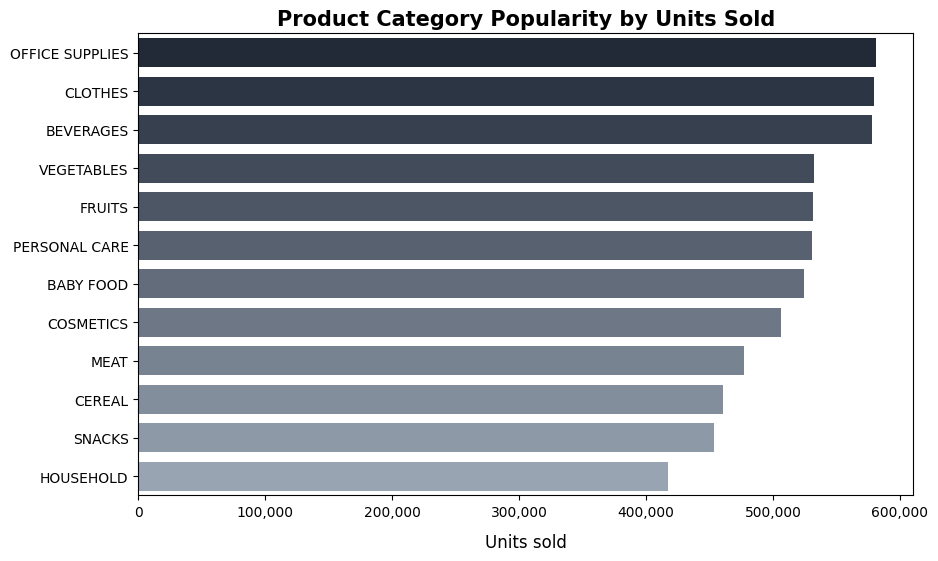

In [ ]:
# Render horizontal bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_popularity.values,
    y=product_popularity.index,
    hue=product_popularity.index,
    palette=sns.color_palette("blend:#1e293b,#94a3b8", n_colors=12),
    legend=False,
    width=0.75)

plt.title("Product Category Popularity by Units Sold", size=15, fontweight="bold")
plt.xlabel("Units sold", size=12, labelpad=10)
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ",")))

plt.show()

### **Аналітичні висновки щодо популярності товарів (Простою мовою)**

* **Що робить нам об'єм:** Наші покупці найчастіше обирають товари повсякденного вжитку. Абсолютними лідерами за кількістю проданих штук є три категорії: **Office Supplies, Clothes та Beverages**. Кожна з них демонструє стабільний масовий попит і впевнено перетнула позначку у **570,000 проданих одиниць**.
* **Замикаючі позиції:** Найменше штучних продажів зафіксовано в категорії **Household** — близько **417,000 одиниць**.
* **Головний висновок для бізнесу:** Попри те, що Household замикає цей рейтинг, попит між усіма 12 категоріями розподілений дуже рівномірно. Різниця між першим та останнім місцем мінімальна. Це означає, що у нас чудово збалансований асортимент і **немає «мертвих» категорій**, які б взагалі не продавалися.

---

### **Product Popularity Insights (Simplified)**

* **What drives our volume:** Our customers clearly lean toward everyday consumer products. The top three absolute volume drivers are **Office Supplies, Clothes, and Beverages**. Each of these categories shows steady, mass-market demand, easily clearing the **570,000 units sold** milestone.
* **The lower end:** The **Household** category sits at the bottom of the volume list, bringing in around **417,000 units sold**.
* **Business Takeaway:** Even though Household ranks last here, our product demand is remarkably well-balanced. The gap between our best and worst sellers is quite small. This means we have a highly stable catalog with **zero "dead weight" or failing categories**—everything we stock actively sells.

## **3.4 Comparative Financial Analysis: Revenue vs. Net Profit**

In [ ]:
# Group financial metrics by category and prepare tidy format for seaborn pairing
grouped_metrics = final_df.groupby("Product category")[["Revenue", "Profit"]].sum().sort_values(by="Revenue", ascending=False).reset_index()

df_melted = pd.melt(grouped_metrics, id_vars=["Product category"], value_vars=["Revenue", "Profit"], var_name="Financial Metric", value_name="Amount")

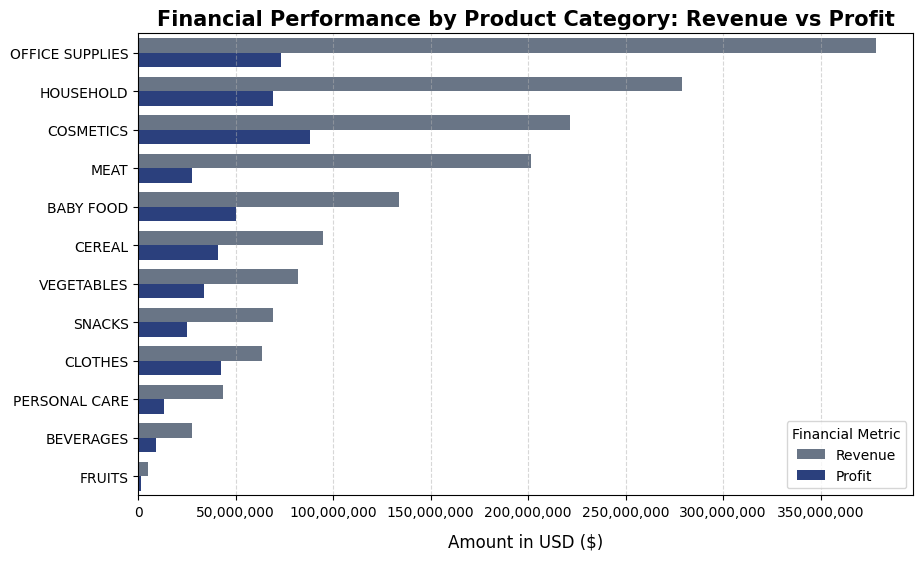

In [ ]:
# Render grouped bar chart
plt.figure(figsize=(10, 6))

df_melted = pd.melt(grouped_metrics, id_vars=["Product category"], value_vars=["Revenue", "Profit"], var_name="Financial Metric", value_name="Amount")
sns.barplot(
    data=df_melted,
    x="Amount",
    y="Product category",
    hue="Financial Metric",
    palette=["#64748b", "#1e3a8a"],
    width=0.75)

plt.title("Financial Performance by Product Category: Revenue vs Profit", size=15, fontweight="bold")
plt.xlabel("Amount in USD ($)", size=12, labelpad=10)
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.ticklabel_format(style="plain", axis="x")

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ",")))

plt.show()

### **Порівняльний фінансовий аналіз: Доходи vs Чистий прибуток**

* **Гігант виручки:** Категорія **Office Supplies** є абсолютним лідером за обсягом доходу, приносячи компанії понад 378 млн.дол. Проте її чистий прибуток становить лише близько 73.4 млн.дол. Це маркер високої собівартості або великих витрат на закупівлю й логістику, які з'їдають фінальну маржу.

* **Великий оборот, малий вихлоп:** Категорії **Household** (дохід 278 млн.дол.) та **Meat** (дохід близько 201 млн.дол.) демонструють наступну тенденцію - попри великі масштаби продажів, стовпчик чистого прибутку є дуже коротким (М'ясо приносить лише 27.3 млн.дол.). Це  маркер низькомаржинального товару. Він добре працює на створення великого грошового обороту, але не на реальну прибутковість.

* **Лідер з прибутковості:** Категорія **Cosmetics** - наша головна фінансова зірка. Вона має помітно меншу виручку, ніж Household (221 млн.дол. проти 278 млн.дол.), проте генерує найбільший чистий прибуток серед усього асортименту - 88 млн.дол. Співвідношення прибутку до доходу тут найвище, що робить косметику найбільш високомаржинальним та вигідним напрямком для бізнесу.

---

### **Financial Efficiency & Margin Insights**

* **The Revenue Giant:** **Office Supplies** is our absolute powerhouse for generating top-line revenue, bringing in over **378 million**. However, its net profit sits at just **73.4 million**. This reveals high production, sourcing, or delivery costs that eat away at its final profit.

* **High Volume, Low Return:** Categories like **Household** (278M revenue) and **Meat** (~201M revenue) show a tricky trend—huge sales volumes, but very short green profit bars (**Meat pulls in just 27.3M net profit**). This is a classic indicator of low-margin goods. They are excellent for keeping cash flowing through the business, but they aren't our primary profit makers.

* **The Real Profit Winner:** **Cosmetics** is our financial superstar. Even though it generates far less revenue than Household (221M vs 278M), it delivers the highest net profit of all: **88 million**. It has the highest profit-to-revenue ratio, making it our most high-margin and financially efficient product line.

---

## **3.5 Geographical Performance Analysis: Volumetric vs. Financial Leaders**

# GEOGRAPHICAL BREAKDOWN (TOP 10 COUNTRIES)

In [ ]:
# 1. Top 10 Countries by Volumetric Sales (Units Sold)
top_10_countries = final_df.groupby("Country")["Units Sold"].sum().sort_values(ascending=False).head(10).reset_index()

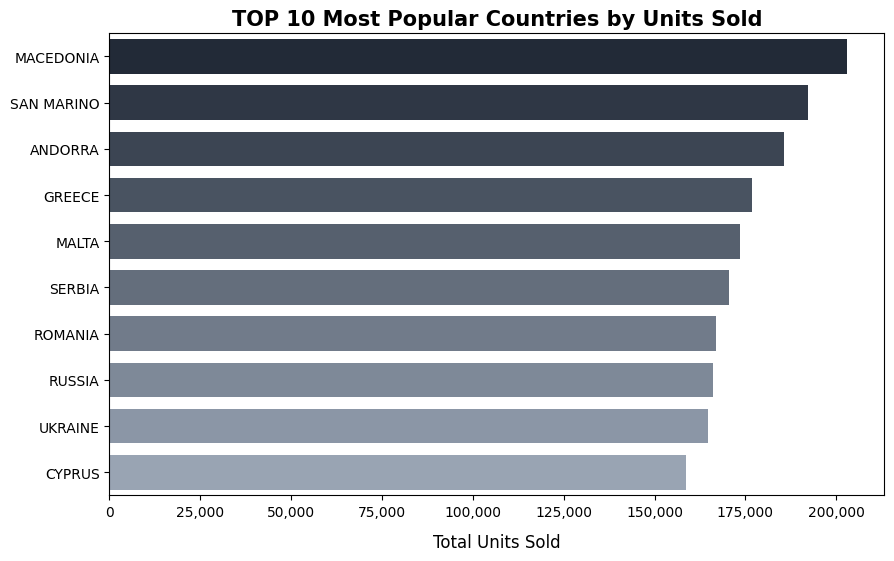

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_countries,
    x="Units Sold",
    y="Country",
    hue="Country",
    palette=sns.color_palette("blend:#1e293b,#94a3b8", n_colors=10),
    width=0.75,
    legend=False
    )

plt.title("TOP 10 Most Popular Countries by Units Sold", size=15, fontweight="bold")
plt.xlabel("Total Units Sold", size=12, labelpad=10)
plt.ylabel("")

plt.ticklabel_format(style="plain", axis="x")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ",")))

plt.show()

In [ ]:
# 2. Top 10 Countries by Financial Performance (Net Profit)
top_10_countries_by_profit = final_df.groupby("Country")["Profit"].sum().sort_values(ascending=False).head(10).reset_index()

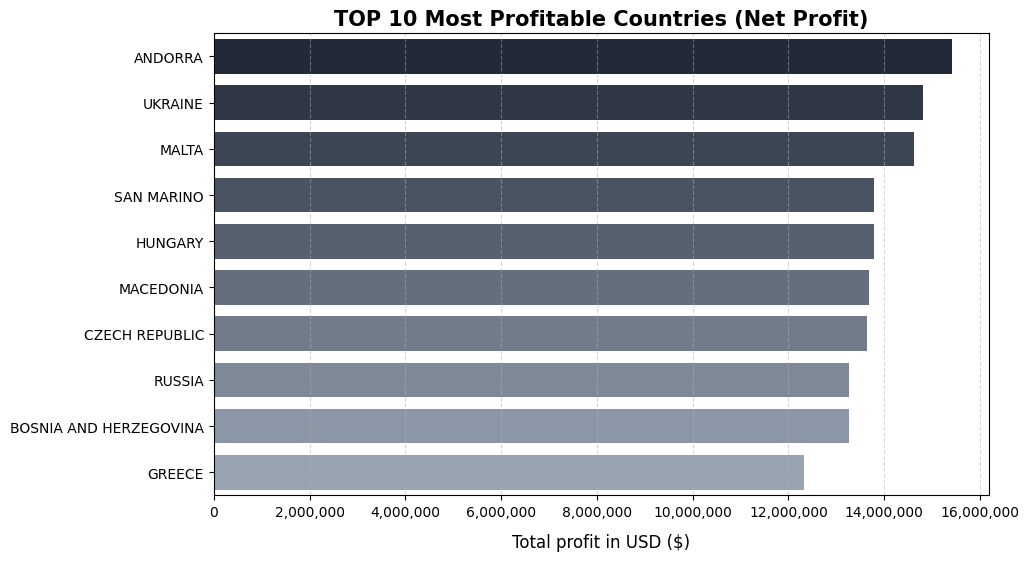

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_countries_by_profit,
    x="Profit",
    y="Country",
    hue="Country",
    palette=sns.color_palette("blend:#1e293b,#94a3b8", n_colors=10),
    width=0.75,
    legend=False
    )

plt.title("TOP 10 Most Profitable Countries (Net Profit)", size=15, fontweight="bold")
plt.xlabel("Total profit in USD ($)", size=12, labelpad=10)
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.ticklabel_format(style="plain", axis="x") # turning off scientific style of values
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ","))) #formating the numbers on the X-axis by adding a comma as a thousands separator
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

### **Географічні інсайти: Об'єми продажів vs Реальний прибуток**

* **Лідери за штучними продажами:** Найбільші обсяги збуту продукції припадають на **Македонію** (понад 200 тис. одиниць), **Сан-Марино** (приблизно 192 тис.) та **Андорру** (185 тис.). Ці країни є головними точками фізичного збуту товарів компанії.

* **Феномен України (Високомаржинальний ринок):** На графіку кількості проданих штук **Україна** посідає передостаннє (9-те) місце із показником близько 164 тис. одиниць. Проте на графіку чистого прибутку Україна має 2-ге місце у світі, згенерувавши майже 15 млн.дол.
  
  **Висновок для бізнесу:** На українському ринку ми продаємо хоч і менше одиниць товару, але це дорогі, преміальні та високомаржинальні позиції. Україна працює супер-ефективно: мінімум логістичних витрат на доставку - максимум чистого фінансового вихлопу.

* **Абсолютний фінансовий лідер:** **Андорра** посідає 1-ше місце за генерацією чистого прибутку (понад 15.4 млн.дол.), а замикає трійку лідерів Мальта (~14.6 млн.дол.).

---

### **Geographical Insights: Volumetric vs. Financial Value**

* **Volume Giants:** The absolute leaders in physical order volume are **Macedonia** (over 200k units), **San Marino** (~192k units), and **Andorra** (185k units). These are our primary physical sales hubs.

* **The Ukraine Phenomenon (High-Margin Strategy):** On the volume chart, **Ukraine** sits near the bottom at 9th place (~164k units). However, on the Net Profit chart, **Ukraine jumps straight to 2nd place globally**, generating nearly 15 M. in net profit!
  
  **Business Takeaway:** This is a vital finding. It proves that while our transaction volume in Ukraine is relatively lower, the local market primarily purchases our most premium, high-ticket, high-margin goods (like Cosmetics). Ukraine is an incredibly efficient market that generates massive profit from fewer shipments.

* **Profit Leader:** **Andorra** claims the global #1 spot for financial performance, delivering over 15.4 M. in net profit, closely followed by Malta (~14.6M) at #3.


## **3.6 Macro-Regional Market Shares**

In [ ]:
# GLOBAL REGIONS ANALYSIS

region_profit = final_df.groupby("Region")["Profit"].sum().sort_values(ascending=False).reset_index()

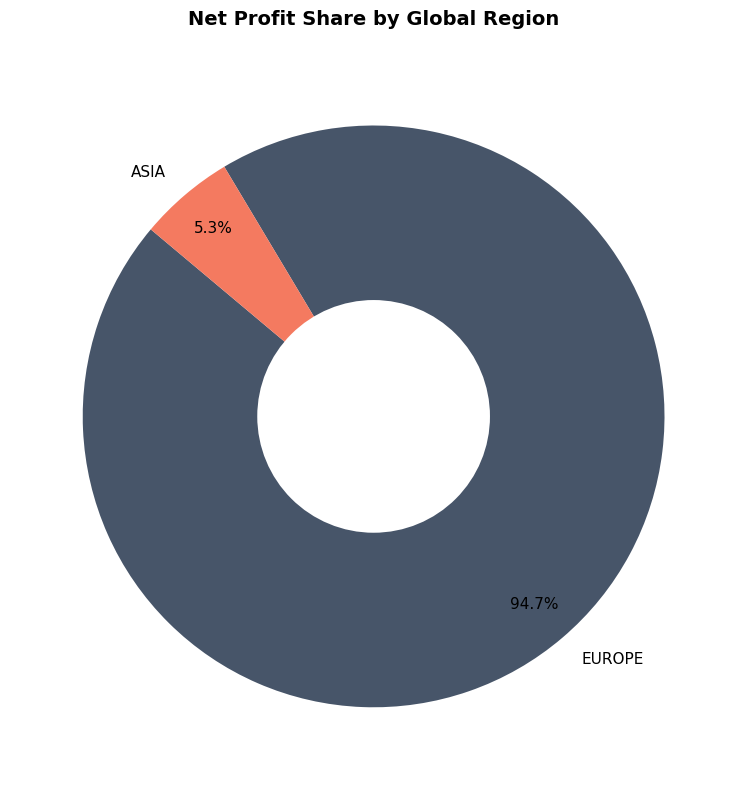

In [ ]:
plt.figure(figsize=(8, 8))
colors = sns.color_palette(["#475569", "#f47a60"], n_colors=len(region_profit))
plt.pie(
    region_profit["Profit"],
    labels=region_profit["Region"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    textprops={"fontsize": 11})

# Render donut transformation
centre_circle = plt.Circle((0,0), 0.40, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Net Profit Share by Global Region", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

### **Аналіз глобальних регіонів**

* **Європейське ядро:** **Європа — це абсолютне економічне серце компанії**, яке приносить колосальні **94.7%** від усього чистого прибутку бізнесу. Фінансова стабільність компанії наразі повністю тримається на цьому регіоні.

* **Азійський горизонт:** **Азія генерує всього 5.3%** прибутку. Попри гігантські масштаби цього ринку, у нас він працює на мінімальних оборотах.

* **Стратегічні рекомендації:**
  1. *Для Європи:* Потрібно утримувати лідерські позиції, захищати ринок від конкурентів та підтримувати поточну стратегію, адже вона доречна й надефективна.
  2. *Для Азії:* Необхідно провести гнутикий операційний аудит (чому частка така маленька?). Азія повинна стати нашою головною зоною для потенційного розширення та масштабування продажів у майбутньому.

  ---


### **Macro-Regional Strategy Insights**

* **The European Core:** **Europe is our absolute economic engine**, driving an overwhelming **94.7%** of the company’s total net profit. The business is heavily dependent on this region for its financial health.

* **The Asian Growth Horizon:** **Asia contributes just 5.3%** of our total net profit. Despite the massive population and commercial scale of the Asian market, our footprint there is currently performing at a bare minimum level.

* **Strategic Guidance:**
  1. *For Europe:* Maintain a protective market strategy, defend our strong positions against competitors, and reinvest in local customer retention.
  2. *For Asia:* Conduct an immediate root-cause operational audit to identify barriers (e.g., poor marketing localized fit or supply chain hurdles). Asia must become our primary zone for future growth and scaling.


## **3.7 Sales Channels: Online vs. Offline Balance**

In [ ]:
# SALES CHANNELS BALANCING

sold_units_sales_channel = final_df.groupby("Sales Channel")["Units Sold"].sum().reset_index()
total_profit_sales_channel = final_df.groupby("Sales Channel")["Profit"].sum().sort_values(ascending=False).reset_index()

In [ ]:
total_profit_sales_channel.style.format({"Profit": "{:,.2f}"}) # output a table with convenient formatting (with commas between thousands)

,Sales Channel,Profit
0,OFFLINE,"238,511,327.41"
1,ONLINE,"235,197,707.65"


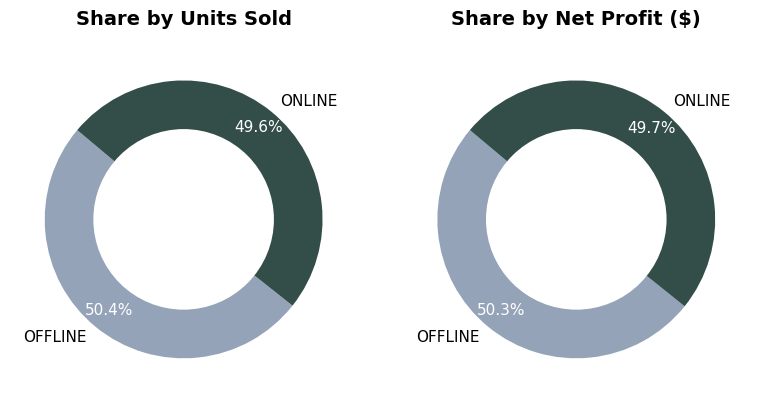

In [ ]:
# Set up side-by-side donut comparison
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
colors = ["#94a3b8", "#334e48"]
text_props = {"fontsize": 12, "fontweight": "bold"} #common settings for text

# Left Donut - Units Sold Share
wedges1, texts1, autotexts1 = ax[0].pie(
    sold_units_sales_channel["Units Sold"],
    labels=sold_units_sales_channel["Sales Channel"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    textprops={"fontsize": 11})
ax[0].set_title("Share by Units Sold", fontsize=14, fontweight='bold', pad=15)

ax[0].add_artist(plt.Circle((0,0), 0.65, fc="white"))
plt.setp(autotexts1, size=11, color="white")

# Right Donut - Profit Share
wedges1, texts1, autotexts2 = ax[1].pie(
    total_profit_sales_channel["Profit"],
    labels=total_profit_sales_channel["Sales Channel"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    textprops={"fontsize": 11})
ax[1].set_title("Share by Net Profit ($)", fontsize=14, fontweight="bold", pad=15)

ax[1].add_artist(plt.Circle((0,0), 0.65, fc="white"))
plt.setp(autotexts2, size=11, color="white")

plt.tight_layout()
plt.show()

### **Аналіз каналів продажів**

* **Ринковий баланс:** Обидва графіки демонструють практично ідеальне співвідношення 50/50. Офлайн-продажі займають 50.4% за штуками та 50.3% за прибутком, тоді як Онлайн-замовлення тримають 49.6% об'єму та 49.7% фінансової частки.

* **Висновок для бізнесу:** Це ідеальний сценарій. Він свідчить про те, що наш інтернет-магазин та фізичні точки продажів розвинені та працюють однаково ефективно. Бізнес міцно стоїть на обох ногах, що мінімізує будь-які ризики.

---

### **Sales Channel Alignment Insights**

* **Perfect Channel Harmony:** The charts show a near-flawless 50/50 equilibrium between our sales vectors. Offline channels make up 50.4% of unit volume and 50.3% of total profit. Meanwhile, Online channels account for 49.6% of volume and 49.7% of total profit.

* **Business Takeaway:** This is an optimal scenario. It indicates that our e-commerce infrastructure and our brick-and-mortar physical channels are performing with equal efficiency. The business stands securely on both channels, minimizing channel risks.

## **3.8 Order Fulfillment Lead Time Analysis by Geography and Category**

In [ ]:
#FEATURE ENGINEERING: LEAD TIME CALCULATION

# Calculate absolute days taken to ship each order
final_df["Days_to_Ship"] = (final_df["Ship Date"] - final_df["Order Date"]).dt.days

In [ ]:
# 1. Lead Time by Product Category (Median)
category_order = final_df.groupby("Product category")["Days_to_Ship"].median().sort_values(ascending=False).reset_index()

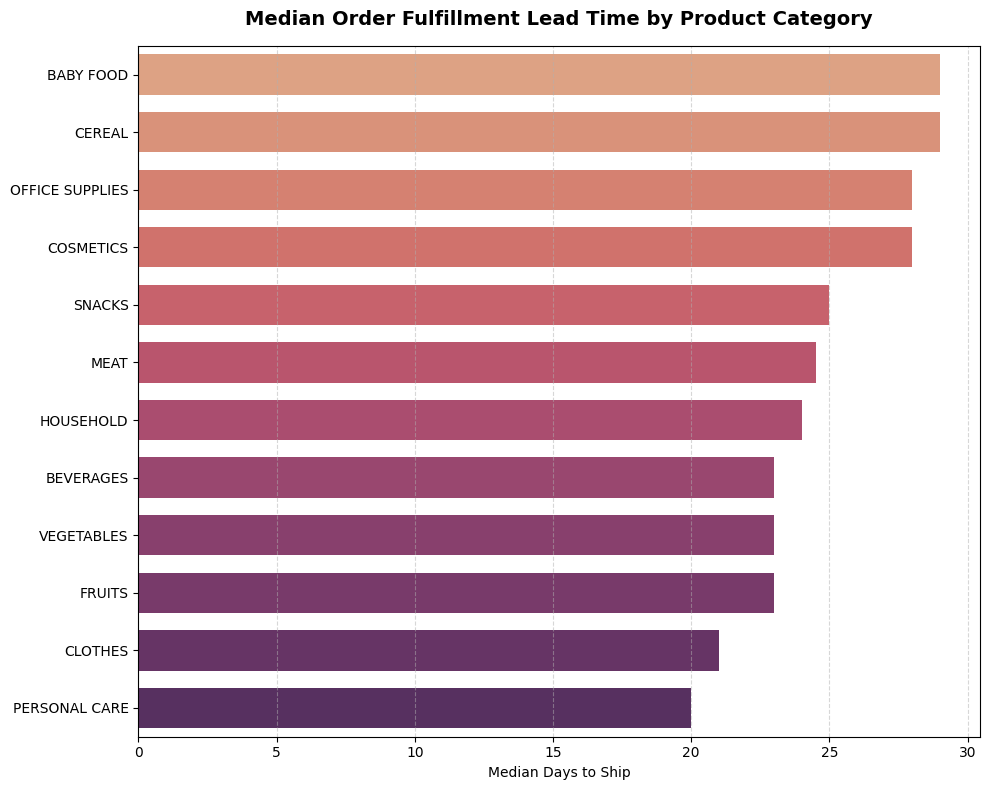

In [ ]:
#creating bar plot
plt.figure(figsize=(10, 8))

sns.barplot(
    data=category_order,
    x="Days_to_Ship",
    y="Product category",
    palette="flare",
    hue="Product category",
    legend=False,
    width=0.7,
    errorbar=("ci", False)
)

plt.title("Median Order Fulfillment Lead Time by Product Category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Median Days to Ship")
plt.ylabel("", fontsize=5)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### **Логістичні інсайти по категоріях товарів**

* **Головні затримки:** Найдовше на складах обробляються та відвантажуються **Baby Food та Cereal** (медіана становить майже 29 днів). Навіть найшвидша категорія, **Personal Care**, займає 20 днів від моменту замовлення до відправки.

* **Операційні ризики:** Дитяче харчування та бакалія мають обмежені терміни придатності та потребують особливих умов зберігання. Показник у місяць на відвантаження різко підвищує ризики псування продукції, списань та отримання скарг від незадоволених клієнтів.

---

### **Product Logistics Insights**

* **The Bottlenecks:** **Baby Food and Cereal** take the longest to ship, stretching to a median of* almost 29 days. Even our fastest category, **Personal Care**, still requires 20 days to leave the warehouse.

* **The Operational Risk:** Baby Food and certain grocery items have strict expiration dates and temperature requirements. Holding these items in transit or warehouse queues for nearly a month significantly increases the risk of product spoilage, write-offs, and customer complaints.

# GEOGRAPHICAL LEAD TIME ANALYSIS

In [ ]:
# 2. Top 10 Slowest Countries by Lead Time (Average)
top10_slow_countries = final_df.groupby("Country")["Days_to_Ship"].mean().sort_values(ascending=False).reset_index().head(10)

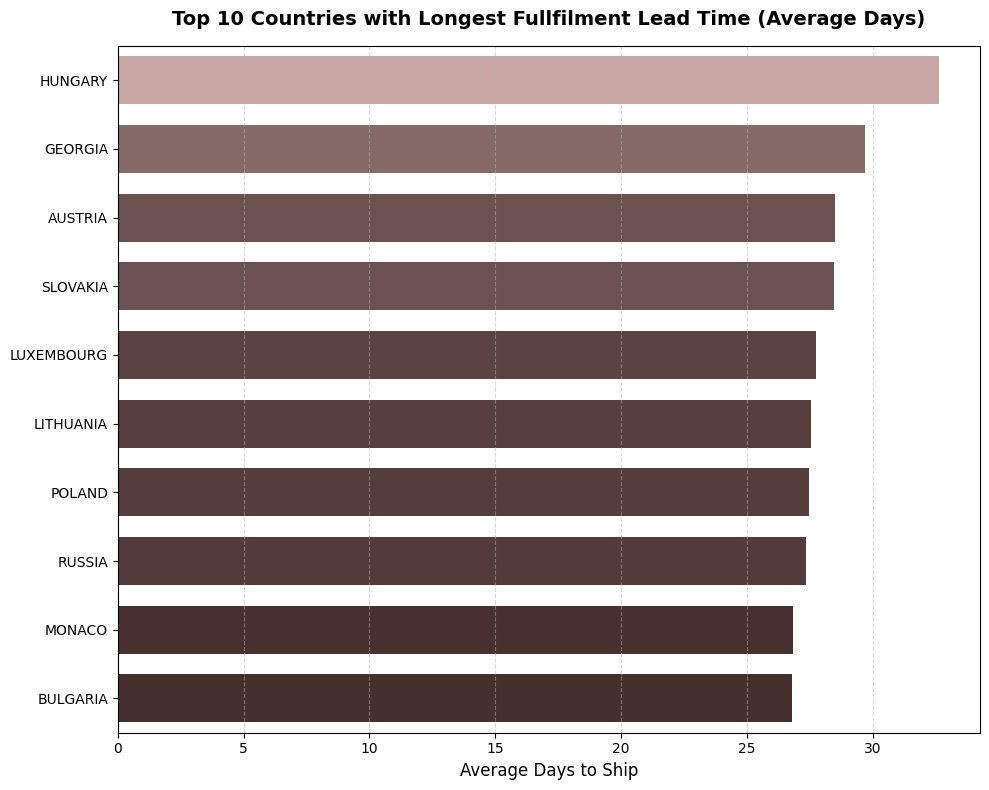

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top10_slow_countries,
    x="Days_to_Ship",
    y="Country",
    palette="blend:#4a2c2a,#cda29e",
    hue="Days_to_Ship",
    legend=False,
    width=0.7,
    errorbar=("ci", False)
)

plt.title("Top 10 Countries with Longest Fullfilment Lead Time (Average Days)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Average Days to Ship", fontsize=12)
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### **Географічні логістичні інсайти**

* **Антилідери за швидкістю:** Абсолютним антилідером за затримками стала **Угорщина**. Середній термін відвантаження замовлення тут складає рекордні 32 дні. Інші країни з Топ-10 відстають ненабагато, тримаючи затримку в районі 27–30 днів.

* **Висновок для бізнесу:** Ці цифри підтверджують серйозні локальні проблеми з логістикою в окремих країнах. Можливо, це пов'язано з митним оформленням або неефективною роботою місцевих кур'єрських та поштових служб.

---

### **Geographical Logistics Insights**

* **Country Logistics Gaps:** **Hungary** is our absolute underperformer for delivery speed, with orders taking an average of 32 days to ship. The remaining top 10 slow countries follow closely behind, averaging between 27 to 30 days.

* **Business Takeaway:** This confirms localized friction points in specific domestic supply chains, custom clearances, or regional fulfillment partners that require immediate standard-operating-procedure reviews.

# MACRO-REGIONAL LEAD TIME BREAKDOWN

In [ ]:
# 3. Grouping by macro-regions and taking the MEAN of days
region_shipment = final_df.groupby("Region")["Days_to_Ship"].mean().sort_values(ascending=False).reset_index()

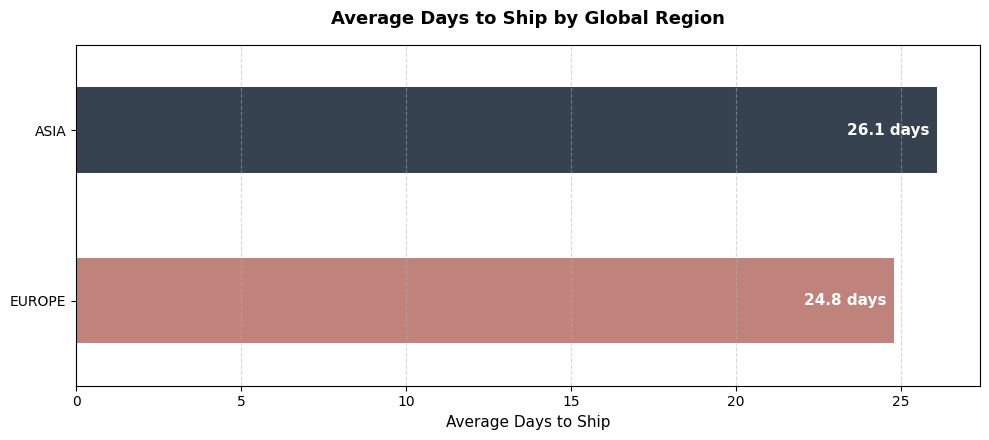

In [ ]:
plt.figure(figsize=(10, 4.5))
ax = plt.subplot(1, 1, 1)

sns.barplot(
    data=region_shipment,
    x="Days_to_Ship",
    y="Region",
    palette=["#334155", "#cc7a6f"],
    hue="Region",
    legend=False,
    width=0.5,
    errorbar=("ci", False)
)

# Add clean visual data labels inside the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f days", padding=-65, color="white", fontweight="bold", fontsize=11)

plt.title("Average Days to Ship by Global Region", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Average Days to Ship", fontsize=11)
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### **Макрорегіональний логістичний висновок**

* **Головне відкриття аналізу:** У середньому відвантаження товару займає 26.1 днів в Азії** та **24.8 днів в Європі.

* **Діагноз для бізнесу:** Різниця між регіонами мізерна — всього 1.3 дня. Це найважливіший висновок: проблема повільного відвантаження не пов'язана з географією (відстанню чи транспортними маршрутами). Вона має внутрішній, системний характер. Причина криється всередині самої компанії: застарілі процеси обробки замовлень, повільне збирання товарів на складах або внутрішня бюрократія.

---

### **Macrographic Logistics Takeaway**

* **The Core Discovery:** On average, shipping takes 26.1 days in Asia and 24.8 days in Europe.
* **Strategic Diagnosis:** The difference between regions is tiny - just 1.3 days. This proves that our long shipping times are not a geographic issue. Instead, it's a deep internal, systemic issue. The root cause likely lies within our own walls: slow order processing, warehouse step inefficiencies, or excessive internal red tape before an order is handed to the courier.

## **4. Financial Impact Analysis: Profit vs. Fulfillment Lead Time**

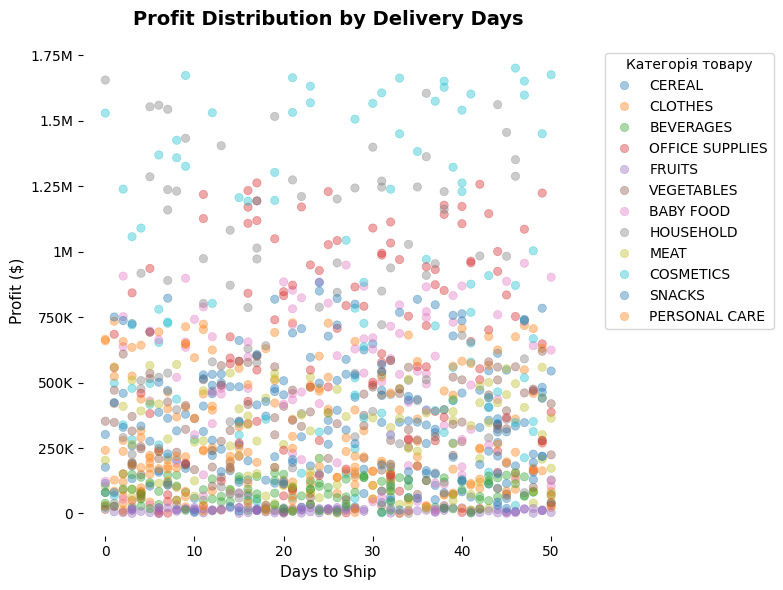

In [ ]:
# 4.1 LEAD TIME VS. PROFITABILITY RELATIONSHIP
# Render descriptive scatter relationship plot

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=final_df,
    x="Days_to_Ship",
    y="Profit",
    alpha=0.4,
    hue="Product category",
    palette="tab10",
    edgecolor=None
    )

plt.legend(title="Категорія товару", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.title("Profit Distribution by Delivery Days",
          fontsize=14,
          pad=15,
          loc="center",
          weight="bold")
plt.xlabel("Days to Ship", fontsize=11)
plt.ylabel("Profit ($)", fontsize=11)

def reformat_large_tick_values(value, tick_number):
    if value >= 1_000_000:
        return f"{value * 1e-6:g}M"
    elif value >= 1_000:
        return f"{value * 1e-3:g}K"
    return f"{value:g}"

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(reformat_large_tick_values)
)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


### **Аналіз фінансового впливу затримок**

* **Головне відкриття:** Діаграма розсіювання чітко демонструє, що між часом обробки замовлення (Days to Ship) та чистим прибутком (Profit) з однієї транзакції немає жодного статистичного зв'язку.

* **Висновок для бізнесу:** Замовлення, які відвантажили швидко, приносять такий самий прибуток, як і замовлення з критичними затримками у 40–50 днів. Це означає, що маржинальність нашого асортименту повністю захищена від операційних збоїв.

* **Важливе застереження**: Хоча повільна робота складів не зменшує чистий прибуток, отриманий «тут і зараз» з конкретного чека, вона створює приховані ризики для бізнесу: сильно псує клієнтський досвід (LTV), знижує лояльність та уповільнює оборотність робочого капіталу компанії.

---

### **Financial Impact Insights**

* **The Core Discovery:** The scatter plot clearly shows **zero statistical correlation** between the number of days it takes to ship an order and the average profit generated.
* **Business Takeaway:** Orders shipped instantly show the exact same profit distribution as orders stuck with critical shipping delays of 40 to 50 days. This means our unit profit margins are completely insulated from fulfillment lag. While slow logistics absolutely hurt customer experience and long-term retention, they do not directly drain or deflate the net profit earned from an individual transaction.
* **Important caveat**: Although slow warehouse operations do not reduce the net profit received "here and now" from a specific check, they create hidden risks for the business: they greatly spoil the customer experience (LTV), reduce loyalty, and slow down the company's working capital turnover.

## **5. Sales Performance & Weekly Dynamics**

In [ ]:
# 5.1 WEEKLY DYNAMICS BY PRODUCT CATEGORY

# Extract day profiles and enforce standard categorical tracking timeline
final_df["Day_of_Week"] = final_df["Order Date"].dt.day_name()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
final_df["Day_of_Week"] = pd.Categorical(final_df["Day_of_Week"], categories=days_order, ordered=True)

In [ ]:
# Group order frequencies
grouped_days_of_week = final_df.groupby(["Day_of_Week", "Product category"], observed=False)["Order ID"].count().reset_index()
grouped_days_of_week = grouped_days_of_week.sort_values("Day_of_Week")

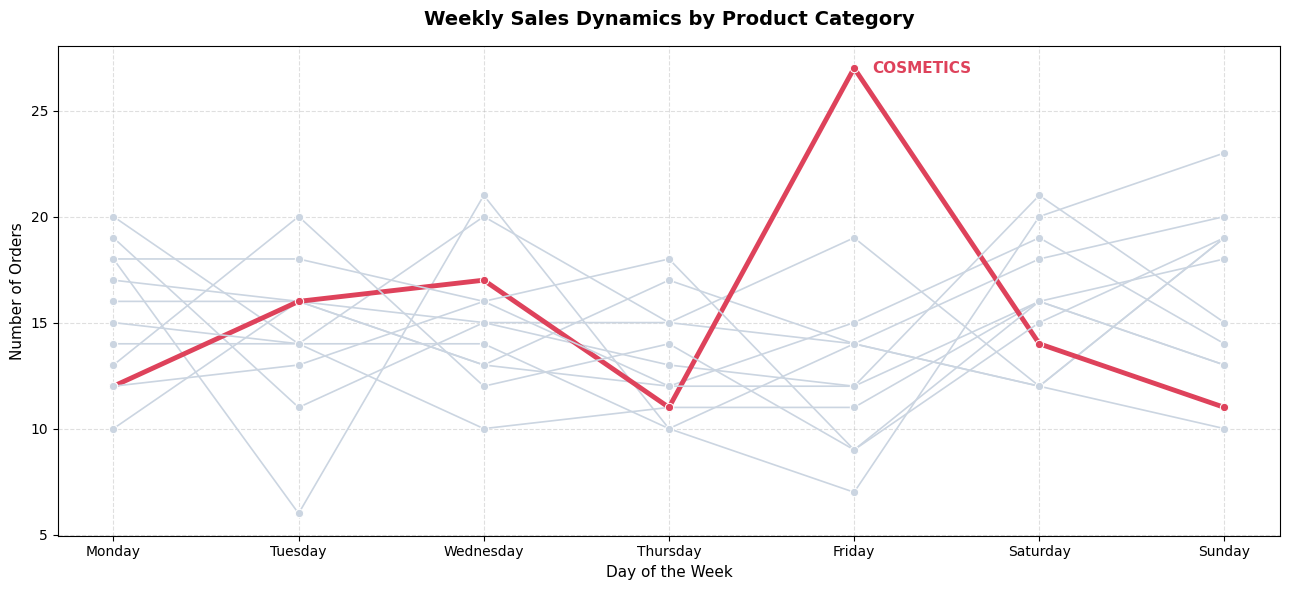

In [ ]:
# Construct targeted color mapping to isolate specific anomalies
all_categories = grouped_days_of_week["Product category"].unique()
cat_colors = {cat: "#de425b" if cat == "COSMETICS" else "#cbd5e1" for cat in all_categories}
cat_sizes = {cat: 3.5 if cat == "COSMETICS" else 1.2 for cat in all_categories}

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=grouped_days_of_week,
    x="Day_of_Week",
    y="Order ID",
    hue="Product category",
    size="Product category",
    palette=cat_colors,
    sizes=cat_sizes,
    marker="o"
)

plt.text(x=4.1, y=27, s="COSMETICS", color="#de425b", fontsize=11, fontweight="bold", va="center")

plt.title("Weekly Sales Dynamics by Product Category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day of the Week", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)
plt.legend([], [], frameon=False)
plt.grid(axis="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Основні висновки:**
* **Пік косметики:** Графік чітко виділяє суттєву аномалію продажів у категорії **Cosmetics** по п'ятницях, де обсяг замовлень різко зростає до тижневого максимуму у 27 замовлень. Цей передвихідний сплеск кардинально виділяється на тлі інших днів.
* **Фоновий тренд:** Більшість інших категорій товарів залишаються сгрупованими в межах стабільного рівня від 10 до 20 замовлень на день без яскраво вираженої сезонності.

---

**Key Insights:**
* **Cosmetics Peak:** The chart highlights a significant sales anomaly in the **Cosmetics** category on Fridays, where order volume sharpens to a weekly high of 27 orders. This strong pre-weekend spike stands out drastically against other days.
* **Background Noise:** Most other product categories remain highly compressed, fluctuating consistently within a baseline of 10 to 20 orders per day without explicit weekly seasonality.

In [ ]:
# 5.2 WEEKLY DYNAMICS BY COUNTRY

# Group order frequencies by day and country
grouped_days_of_week_2 = final_df.groupby(["Day_of_Week", "Country"],  observed=False)["Order ID"].count().reset_index()
all_countries = grouped_days_of_week_2["Country"].unique()

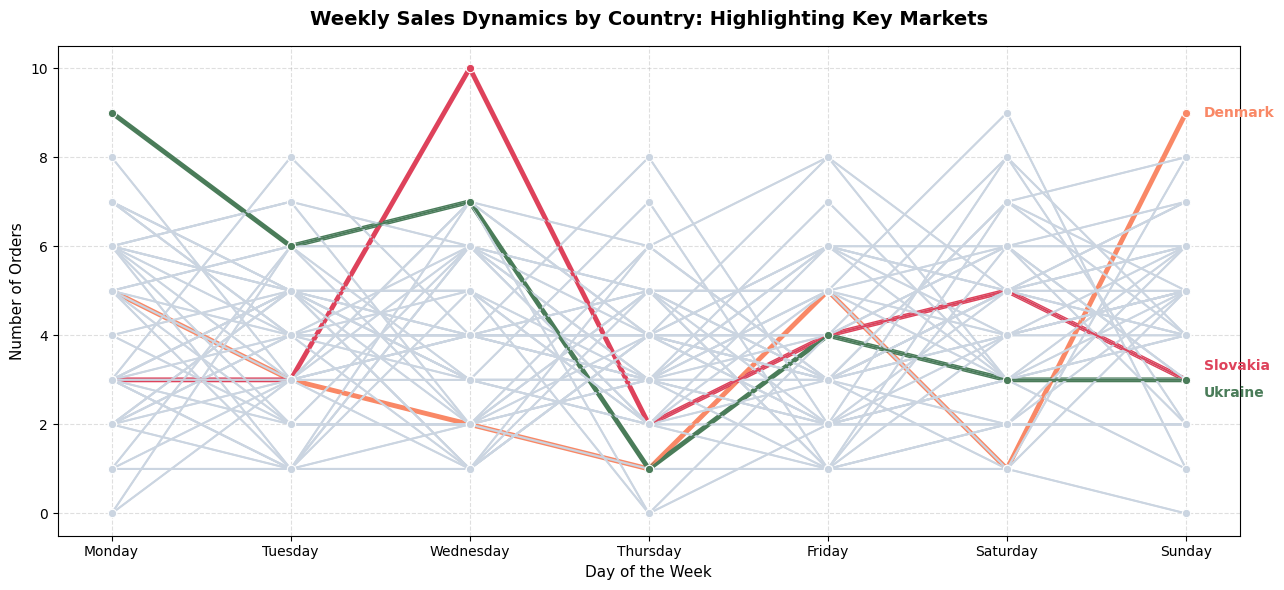

In [ ]:
# Construct targeted color mapping to isolate specific anomalies
colors_dict = {country: "#cbd5e1" for country in all_countries}
sizes_dict = {country: 1.2 for country in all_countries}

# Highlight key focus markets
colors_dict.update({"SLOVAKIA": "#de425b", "DENMARK": "#f98866", "UKRAINE": "#4a7c59"})
sizes_dict.update({"SLOVAKIA": 3.5, "DENMARK": 3.5, "UKRAINE": 3.5})

plt.figure(figsize=(13, 6))

# Plot background baseline countries first, then layer key focus markets on top
for country in all_countries:
    country_data = grouped_days_of_week_2[grouped_days_of_week_2["Country"] == country]
    sns.lineplot(
        data=country_data, x="Day_of_Week", y="Order ID",
        color=colors_dict[country], linewidth=sizes_dict[country],
        marker="o" if sizes_dict[country] > 1.2 else None, sort=False
    )
sns.lineplot(
    data=grouped_days_of_week_2,
    x="Day_of_Week",
    y="Order ID",
    hue="Country",
    palette=colors_dict,
    sizes=sizes_dict,
    marker="o",
    sort=False
)

plt.text(x=6.1, y=9.0, s="Denmark", color="#f98866", fontweight="bold", va="center")
plt.text(x=6.1, y=3.3, s="Slovakia", color="#de425b", fontweight="bold", va="center")
plt.text(x=6.1, y=2.7, s="Ukraine", color="#4a7c59", fontweight="bold", va="center")

plt.title("Weekly Sales Dynamics by Country: Highlighting Key Markets", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day of the Week", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)
plt.legend([], [], frameon=False)
plt.grid(axis="both", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

**Основні висновки:**
* **Ідентифікація ринкових аномалій:** Виділення ключових країн дозволила виявити індивідуальні графіки купівельної активності:
  * **Словаччина** демонструє потужний сплеск у середині тижня, досягаючи піку в 10 замовлень у середу, що значно перевищує її стандартний рівень у 2–3 замовлення.
  * **Україна** забезпечує активність на початку тижня з чітким піком у понеділок (9 замовлень), після чого обсяги плавно стабілізуються ближче до вихідних.
  * **Данія** працює за протилежним графіком, показуючи стабільне зростання наприкінці тижня з максимумом у 9 замовлень у неділю.

  ---

  **Key Insights:**
* **Market Anomaly Identification:** Selectioning key countries reveals highly individualized consumer purchasing patterns:
  * **Slovakia** experiences a major mid-week surge, hitting a dominant peak of 10 orders on Wednesdays, outperforming its standard 2–3 order baseline.
  * **Ukraine** drives early-week momentum with a clear peak on Mondays (9 orders), gradually stabilizing toward the weekend.
  * **Denmark** operates on an opposite schedule, showing steady growth later in the week and reaching a maximum of 9 orders on Sundays.

In [ ]:
# 5.3 WEEKLY DYNAMICS BY GLOBAL REGION

# Group order frequencies by day and region
grouped_days_of_week_3 = final_df.groupby(["Day_of_Week", "Region"],  observed=False)["Order ID"].count().reset_index()

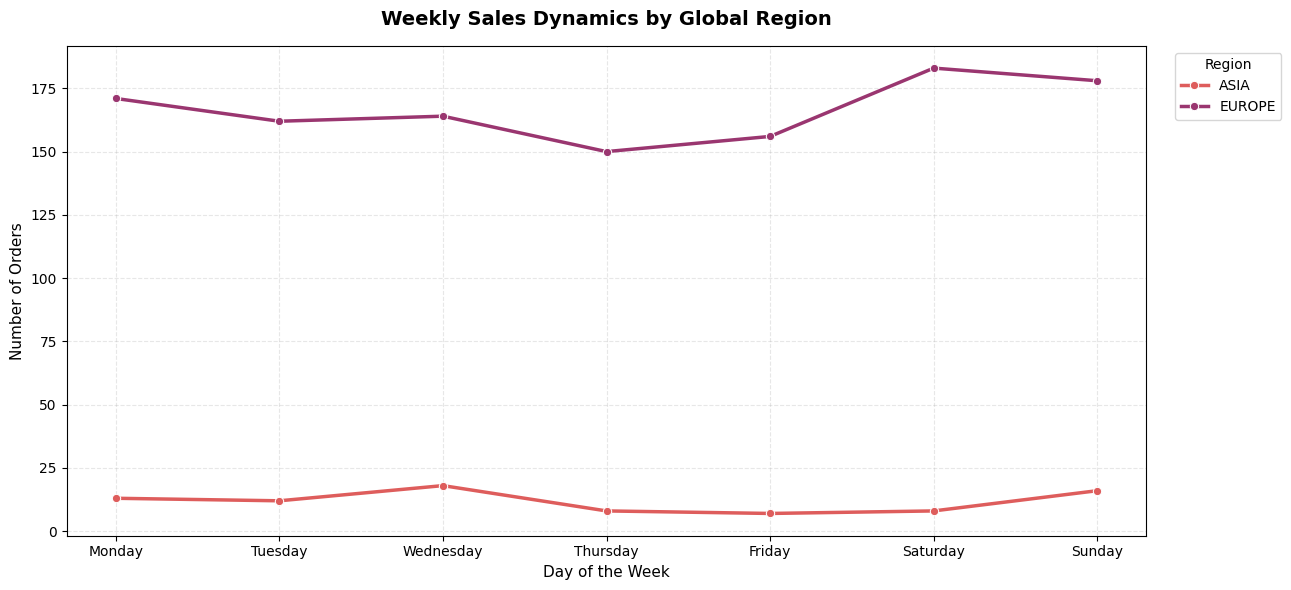

In [ ]:
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=grouped_days_of_week_3,
    x="Day_of_Week",
    y="Order ID",
    hue="Region",
    palette="flare",
    marker="o",
    linewidth=2.5,
    sort=False
)

plt.title("Weekly Sales Dynamics by Global Region", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day of the Week", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)

plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.grid(axis="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Основні висновки:**
* **Абсолютне регіональне домінування:** Графік наочно демонструє, що **Європа** є основним драйвером продажів, утримуючи колосальний обсяг від 150 до 183 замовлень щодня. Пік активності припадає на суботу, а також високі показники спостерігаються в понеділок.
* **Нішева присутність:** Регіон **Азія** займає сегмент із низькою, але стабільною активністю в межах 7–18 замовлень на день, досягаючи максимуму в середу. Такий розрив у масштабах чітко визначає Європу як ключовий цільовий ринок.

---

**Key Insights:**
* **Absolute Regional Dominance:** The chart clearly illustrates that **Europe** is the primary revenue driver, maintaining a massive volume between 150 and 183 orders per day. Its performance peaks on Saturdays and remains strong on Mondays.
* **Niche Market Presence:** The **Asia** region occupies a segment with low, stable activity fluctuating between 7 and 18 orders daily, reaching its maximum volume on Wednesdays. The scale gap highlights Europe as the core target market.

In [ ]:
# 5.4 DAY-OF-WEEK SEASONALITY ANALYSIS

# Group transactional data to spot short-term category fluctuations
week_sales_trend = final_df.groupby(["Day_of_Week", "Product category"], observed=False)["Order ID"].count().reset_index()

In [ ]:
# Extract variability (Max-Min dispersion delta) to isolate seasonal categories
week_check = week_sales_trend.groupby("Product category")["Order ID"].agg(["max", "min"])
week_check["delta"] = week_check["max"] - week_check["min"]

In [ ]:
# Extract the Top 3 categories exhibiting highest intra-week seasonality
seasonal_week_cats = week_check.sort_values(by="delta", ascending=False).head(3).index.tolist()
filtered_week_sales = week_sales_trend[week_sales_trend["Product category"].isin(seasonal_week_cats)]

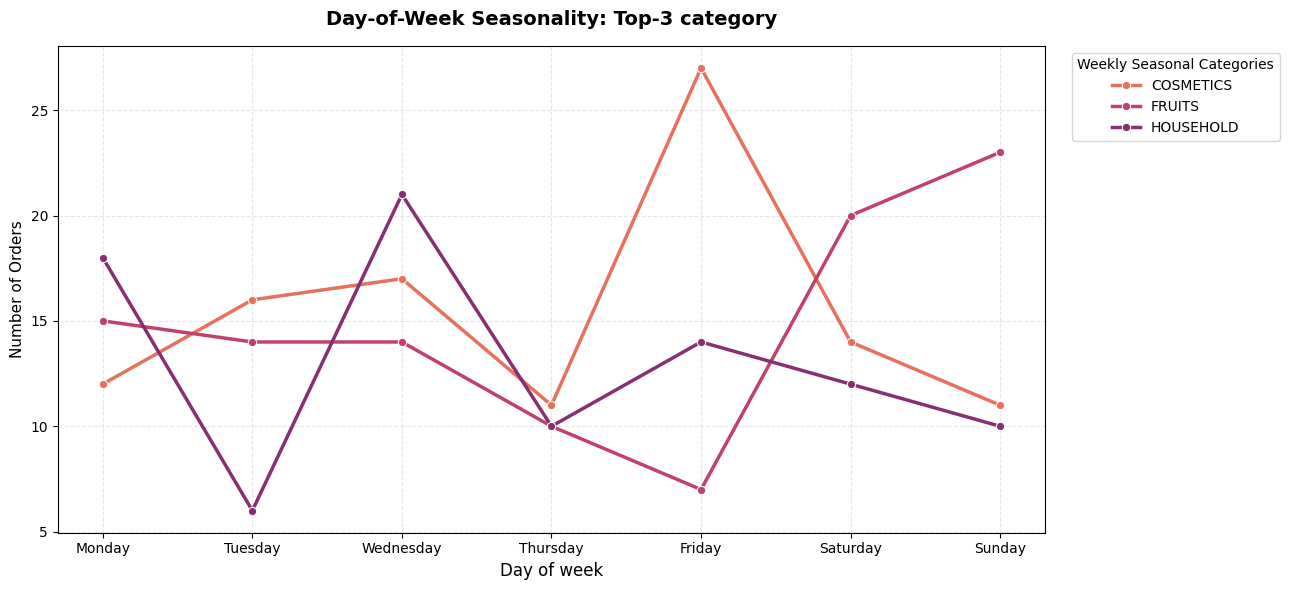

In [ ]:
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=filtered_week_sales,
    x="Day_of_Week",
    y="Order ID",
    hue="Product category",
    marker="o",
    linewidth=2.5,
    palette="flare",
    sort=False
)

plt.title("Day-of-Week Seasonality: Top-3 category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day of week", fontsize=12)
plt.ylabel("Number of Orders", fontsize=11)

plt.legend(title="Weekly Seasonal Categories", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Основні висновки:**
* **Взаємодоповнююча динаміка:** Топ-3 категорії демонструють абсолютно різні тижневі піки, що свідчить про відмінності в поведінці споживачів:
  * **Fruits (Фрукти)** показують зростаючий тренд ближче до вихідних, піднімаючись із мінімуму (7 замовлень) у п'ятницю до піку в неділю (23 замовлення).
  * **Household (Господарські товари)** у піку в середині тижня, в середу (21 замовлення), після різкого стрибка з вівторка (6 замовлень).
  * **Cosmetics (Косметика)** стабільно тримаються на початку тижня перед різким зростанням у п'ятницю (27 замовлень).

  **Key Insights:**
* **Complementary Dynamics:** The top 3 categories exhibit distinct, non-overlapping weekly peaks, suggesting different consumer behaviors:
  * **Fruits** demonstrate an upward weekend trend, growing from a Friday low (7 orders) to a weekly peak on Sunday (23 orders).
  * **Household** goods peak mid-week on Wednesdays (21 orders), following a sharp recovery from a Tuesday minimum (6 orders).
  * **Cosmetics** maintain steady performance early in the week before shaarp growth on Fridays (27 orders).